# Tutorial: Simulator to Forecast Deep Dive

This vignette walks through a realistic synthetic workflow in `motac`: we build a mobility-constrained process on a **10x10 grid** for roughly **one year**, fit a marked Hawkes model, produce posterior-predictive forecasts, and evaluate temporal and spatial forecast quality.

The goal is not only to run code, but to understand what each step contributes:

1. **Simulation design**: specify marks, spatial connectivity, temporal memory, and observation noise.
2. **Exploration**: inspect generated dynamics before fitting.
3. **Model fitting**: estimate parameters with MAP ensemble and inspect stability diagnostics.
4. **Forecasting**: sample future trajectories and summarize uncertainty.
5. **Backtesting**: evaluate calibration and spatial accuracy under rolling-origin splits.

This notebook is intended for local execution with JIT enabled (GPU used automatically when available), then committed with outputs for docs rendering.

In [1]:
import time
NOTEBOOK_START_TS = time.perf_counter()

import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from motac import (
    GridSpec,
    HawkesSimParams,
    HawkesSimNoise,
    HawkesModelSpec,
    MobilityHawkesModel,
    FitConfig,
    make_grid_stencil,
    make_grid_edgelist,
    simulate_counts,
    rolling_backtest,
    aggregate_daily_totals,
    aggregate_mark_totals,
)

plt.style.use('seaborn-v0_8-whitegrid')

devices = jax.devices()
gpu_devices = [d for d in devices if d.platform == "gpu"]
print("Detected devices:", devices)
if gpu_devices:
    print(f"Using GPU backend with {len(gpu_devices)} GPU device(s):", gpu_devices)
else:
    print("No GPU backend detected; JAX will run on", jax.default_backend())

/home/oj/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Detected devices: [CpuDevice(id=0)]
No GPU backend detected; JAX will run on cpu


## 1) Configure a realistic synthetic world

We now define a simulation setting that is intentionally richer than a toy example:

- **Spatial support**: `GridSpec(shape=(10, 10))` gives 100 nodes.
- **Time horizon**: `T=365` daily bins.
- **Marks**: three event types with asymmetric cross-excitation.
- **Connectivity**: a Gaussian stencil for spatial propagation.
- **Observation family**: NB2 (`obs="nb2"`) so variance can exceed mean.

### Key constructor arguments

- `HawkesSimParams.mu`: baseline per-node/per-mark intensity (scalar or array).
- `HawkesSimParams.alpha_from`: source-mark excitation strength.
- `HawkesSimParams.P_from_to`: row-stochastic mark transition matrix.
- `HawkesSimParams.rho`: temporal decay per mark and basis.
- `HawkesSimParams.w_time`: basis-mixture weights per mark.
- `HawkesSimNoise`: optional thinning and temporal/spatial jitter post-processing.

In [2]:
grid = GridSpec(shape=(10, 10))
num_nodes = grid.shape[0] * grid.shape[1]
marks = ("battle", "explosion", "protest")

stencil = make_grid_stencil(kind="gaussian", size=5, sigma=1.2)
_ = make_grid_edgelist(grid, neighbourhood="moore")

params = HawkesSimParams(
    mu=0.012,
    alpha_from=jnp.array([0.23, 0.19, 0.15], dtype=jnp.float32),
    P_from_to=jnp.array([
        [0.70, 0.20, 0.10],
        [0.25, 0.60, 0.15],
        [0.20, 0.25, 0.55],
    ], dtype=jnp.float32),
    rho=jnp.array([
        [0.62, 0.88],
        [0.58, 0.85],
        [0.54, 0.81],
    ], dtype=jnp.float32),
    w_time=jnp.array([
        [0.74, 0.26],
        [0.66, 0.34],
        [0.58, 0.42],
    ], dtype=jnp.float32),
    obs="nb2",
    concentration=18.0,
)
noise = HawkesSimNoise(thinning_p=0.985, jitter_time_p=0.01, jitter_space_p=0.01)

## 2) Simulate one year of counts

`simulate_counts(...)` rolls the latent state forward with `jax.lax.scan`, applies spatial propagation, and samples observed counts from the selected observation model.

The most important arguments in this call are:

- `T`: number of time bins to simulate.
- `connectivity`: spatial operator object (here a Gaussian stencil).
- `params`: process and observation parameters.
- `noise`: optional post-simulation perturbations.
- `seed`: deterministic reproducibility for this run.

In [3]:
data = simulate_counts(
    T=365,
    grid=grid,
    num_nodes=num_nodes,
    marks=marks,
    connectivity=stencil,
    params=params,
    noise=noise,
    seed=7,
)

print("Tensor shape [T,J,M]:", data.y.shape)
print("Total events:", float(np.asarray(data.y).sum()))

Tensor shape [T,J,M]: (365, 100, 3)
Total events: 3922.0


In [4]:
daily = aggregate_daily_totals(data.y)
mark_totals = aggregate_mark_totals(data.y)

y_np = np.asarray(data.y)
usable_days = (y_np.shape[0] // 7) * 7
weekly_totals = y_np[:usable_days].reshape((-1, 7, num_nodes, len(marks))).sum(axis=(1, 2, 3))

print("Daily totals summary:")
print(daily["total"].describe(percentiles=[0.1, 0.5, 0.9]))
print("\nPer-mark totals:")
print(mark_totals)
print("\nFirst 6 weekly totals:", weekly_totals[:6])

Daily totals summary:
count    365.000000
mean      10.745206
std        3.380334
min        2.000000
10%        7.000000
50%       11.000000
90%       15.000000
max       23.000000
Name: total, dtype: float64

Per-mark totals:
   mark   total
0     0  1722.0
1     1  1280.0
2     2   920.0

First 6 weekly totals: [50. 71. 80. 85. 81. 68.]


## 3) Visualize temporal dynamics

Before fitting, always inspect the synthetic series for plausible behavior:

- Are marks active on similar scales?
- Do we see bursts and persistence consistent with self-excitation?
- Is total volatility plausible for the chosen baseline and noise settings?

These checks catch unrealistic simulation settings early.

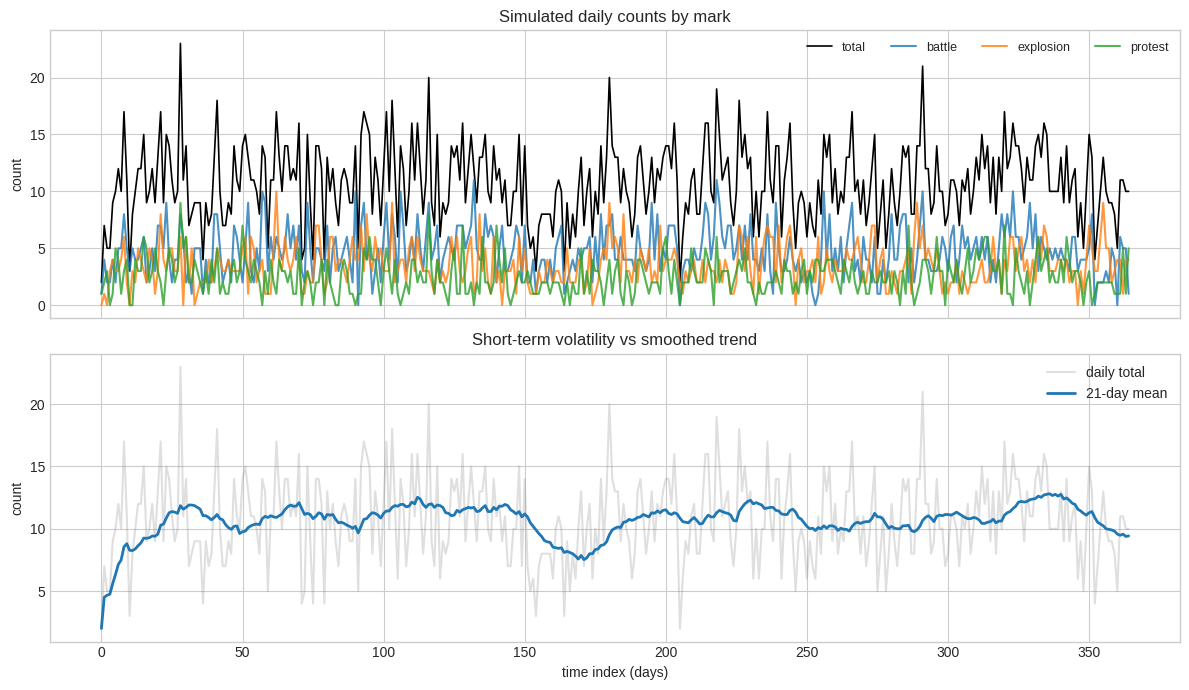

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(daily['t'], daily['total'], color='black', linewidth=1.2, label='total')
for m in range(len(marks)):
    axes[0].plot(daily['t'], daily[f'mark_{m}'], alpha=0.8, label=marks[m])
axes[0].set_title('Simulated daily counts by mark')
axes[0].set_ylabel('count')
axes[0].legend(ncol=4, fontsize=9)

rolling_21d = daily['total'].rolling(21, min_periods=1).mean()
axes[1].plot(daily['t'], daily['total'], alpha=0.25, color='gray', label='daily total')
axes[1].plot(daily['t'], rolling_21d, color='tab:blue', linewidth=2.0, label='21-day mean')
axes[1].set_title('Short-term volatility vs smoothed trend')
axes[1].set_xlabel('time index (days)')
axes[1].set_ylabel('count')
axes[1].legend()

plt.tight_layout()

## 4) Visualize spatial structure and hotspots

The map below aggregates each mark over the full simulated year. Interpreting this figure helps answer:

- Which marks are spatially concentrated vs diffuse?
- Are there persistent hotspots that a forecast should recover?
- Is mark-specific geography aligned with the designed excitation matrix?

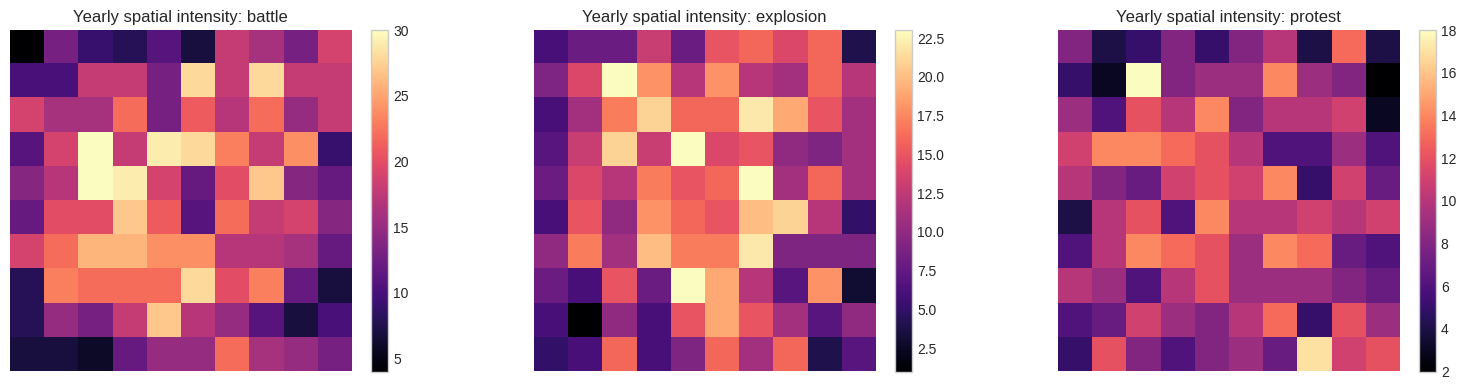

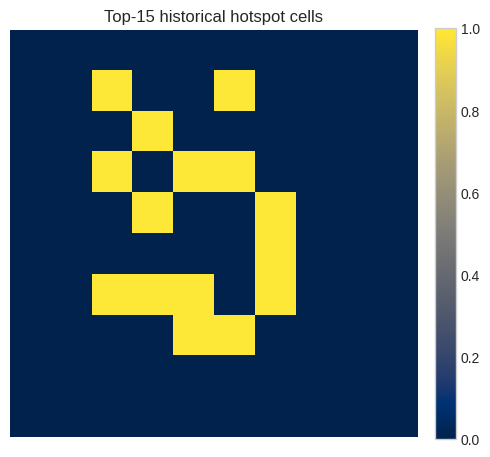

In [6]:
y_np = np.asarray(data.y)
H, W = grid.shape

fig, axes = plt.subplots(1, len(marks), figsize=(16, 4))
for i, mark in enumerate(marks):
    agg = y_np[:, :, i].sum(axis=0).reshape(H, W)
    im = axes[i].imshow(agg, cmap='magma')
    axes[i].set_title(f'Yearly spatial intensity: {mark}')
    axes[i].axis('off')
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
plt.tight_layout()

spatial_total = y_np.sum(axis=(0, 2))
k_hot = 15
top_idx = np.argpartition(spatial_total, -k_hot)[-k_hot:]
hotspot_mask = np.zeros_like(spatial_total)
hotspot_mask[top_idx] = 1

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(hotspot_mask.reshape(H, W), cmap='cividis')
ax.set_title(f'Top-{k_hot} historical hotspot cells')
ax.axis('off')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

## 5) Fit a forecasting model

We use `MobilityHawkesModel` with `HawkesModelSpec` to define model structure and then run MAP ensemble fitting.

### Key model arguments

- `temporal_bases=2`: short-memory + long-memory components per mark.
- `observation="nb2"`: fit overdispersed counts with Negative Binomial 2 likelihood.
- `backend="auto"`: infer `conv` vs `edges` from the attached connectivity object.
- `normalise_spatial_kernel` and `normalise_time_kernel`: optional gain controls for sensitivity analyses.

`FitConfig` controls optimization budget and ensemble size. Here we keep settings moderate to support local end-to-end execution.

In [7]:
spec = HawkesModelSpec(
    marks=marks,
    temporal_bases=2,
    observation="nb2",
    backend="auto",
    normalise_spatial_kernel=True,
    normalise_time_kernel=False,
)
model = MobilityHawkesModel(spec)

fit_cfg = FitConfig(
    map_steps=50,
    map_ensemble_size=3,
    map_patience=15,
)
fit = model.fit(data, method="map_ensemble", config=fit_cfg, seed=11)
print("fit method:", fit.method)
print("posterior draws retained:", fit.diagnostics.get("num_posterior_samples"))

fit method: map_ensemble
posterior draws retained: 3


## 5.1) Stability diagnostics from fitted excitation

Before forecasting, inspect effective excitation spectral-radius diagnostics from the fit. Values near or above 1 can indicate potentially unstable excitation dynamics.

In [8]:
print("mean spectral radius:", fit.diagnostics["excitation_spectral_radius_mean"])
print("max spectral radius:", fit.diagnostics["excitation_spectral_radius_max"])
print("subcritical fraction:", fit.diagnostics["excitation_subcritical_fraction"])

mean spectral radius: 0.4770739475886027
max spectral radius: 0.5114868879318237
subcritical fraction: 1.0


## 6) Generate posterior-predictive forecasts

`model.forecast(...)` draws trajectories from the fitted parameter samples and propagates them autoregressively.

Important forecasting arguments:

- `horizon`: forecast length in bins (days here).
- `num_samples`: number of predictive trajectories.
- `quantile_levels`: uncertainty summary levels extracted from samples.
- `seed`: deterministic rollout reproducibility.

In [9]:
forecast = model.forecast(
    data,
    fit,
    horizon=21,
    num_samples=60,
    seed=13,
    quantile_levels=(0.05, 0.5, 0.95),
)
print("Forecast sample tensor [S,H,J,M]:", forecast.y_samples.shape)
print("Forecast total mean count:", float(np.asarray(forecast.mean).sum()))

Forecast sample tensor [S,H,J,M]: (60, 21, 100, 3)
Forecast total mean count: 227.4000244140625


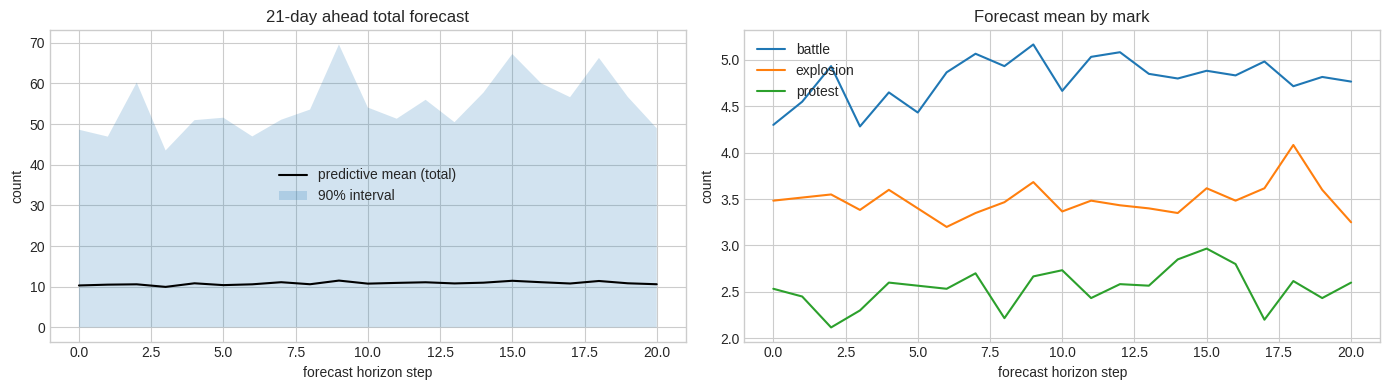

In [10]:
pred_daily_total = np.asarray(forecast.mean).sum(axis=(1, 2))
q05_daily_total = np.asarray(forecast.quantiles[0.05]).sum(axis=(1, 2))
q95_daily_total = np.asarray(forecast.quantiles[0.95]).sum(axis=(1, 2))

pred_daily_by_mark = np.asarray(forecast.mean).sum(axis=1)  # [H, M]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = np.arange(len(pred_daily_total))
axes[0].plot(x, pred_daily_total, label='predictive mean (total)', color='black')
axes[0].fill_between(x, q05_daily_total, q95_daily_total, alpha=0.2, label='90% interval')
axes[0].set_title(f'{len(pred_daily_total)}-day ahead total forecast')
axes[0].set_xlabel('forecast horizon step')
axes[0].set_ylabel('count')
axes[0].legend()

for m, mark in enumerate(marks):
    axes[1].plot(x, pred_daily_by_mark[:, m], label=mark)
axes[1].set_title('Forecast mean by mark')
axes[1].set_xlabel('forecast horizon step')
axes[1].set_ylabel('count')
axes[1].legend()

plt.tight_layout()

## 7) Evaluate with rolling-origin backtesting

A single forecast is not enough to judge reliability. We therefore run repeated rolling-origin splits and compute proper scoring and hotspot metrics.

Configuration choices below are intentionally conservative for local runtime:

- `min_train=196` (roughly 6.5 months burn-in)
- `horizon=14` days per split
- `step=28` days between origins
- lightweight MAP fit per split to keep notebook latency manageable.

In [11]:
bt = rolling_backtest(
    model,
    data,
    horizon=14,
    step=28,
    min_train=196,
    fit_method="map_ensemble",
    fit_config=FitConfig(map_steps=20, map_ensemble_size=2, map_patience=6),
    forecast_samples=40,
    seed=21,
)

print("Number of rolling splits:", len(bt.splits))
bt.metrics.head()

Number of rolling splits: 6


,split,origin_index,log_score,crps,coverage_90,hotspot_recall
0,0,195,-0.177207,0.036904,0.981905,1.0
1,1,223,-0.180247,0.038183,0.981190,1.0
2,2,251,-0.171925,0.036097,0.980238,1.0
3,3,279,-0.187898,0.040521,0.979048,1.0
4,4,307,-0.185684,0.039971,0.981190,1.0


In [12]:
summary = bt.metrics[["log_score", "crps", "coverage_90", "hotspot_recall"]].describe().T

print("Backtest metric summary across rolling splits:")
summary

print(
    f"\nMean 90% interval coverage: {summary.loc['coverage_90', 'mean']:.3f}"
    f" (target ~0.90)"
)
print(f"Mean hotspot recall: {summary.loc['hotspot_recall', 'mean']:.3f}")

Backtest metric summary across rolling splits:

Mean 90% interval coverage: 0.982 (target ~0.90)
Mean hotspot recall: 1.000


## 8) Spatial forecast diagnostics and hotspot overlap

Aggregate scores can hide important geography. We therefore compute split-by-split spatial error diagnostics and inspect map-level agreement for the final rolling split.

In particular, we track:

- **Spatial MAE / RMSE** over the forecast horizon,
- **Spatial correlation** between predicted and observed node totals,
- **Top-k hotspot overlap** (intersection of predicted vs observed hotspot cells).

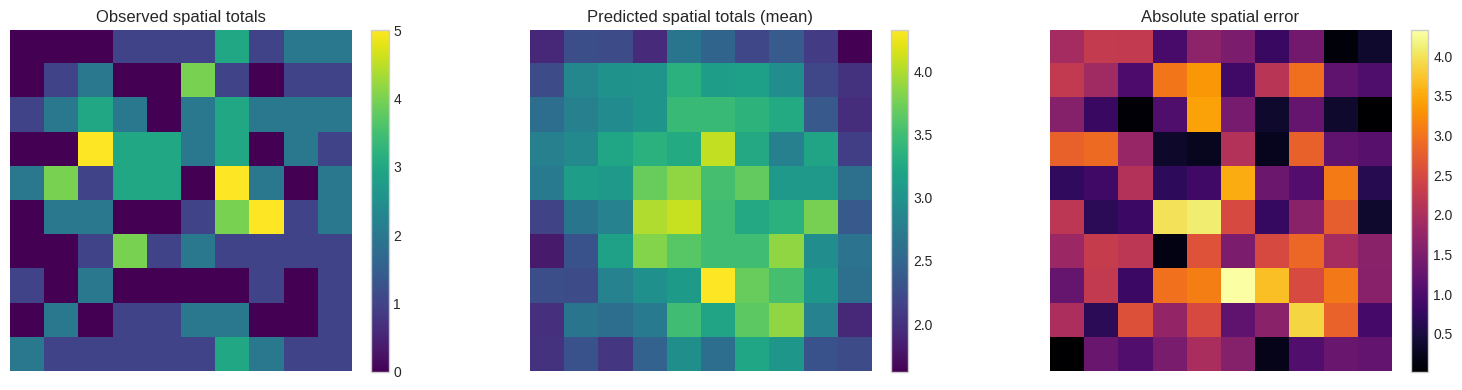

In [13]:
def safe_corr(a, b):
    a = a.reshape(-1)
    b = b.reshape(-1)
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

rows = []
k_hot = 15

for i, (split, fc) in enumerate(zip(bt.splits, bt.forecasts)):
    y_true_spatial = np.asarray(split.test.y).sum(axis=(0, 2)).reshape(H, W)
    y_pred_spatial = np.asarray(fc.mean).sum(axis=(0, 2)).reshape(H, W)
    err = y_pred_spatial - y_true_spatial

    yt_flat = y_true_spatial.reshape(-1)
    yp_flat = y_pred_spatial.reshape(-1)
    top_true = np.argpartition(yt_flat, -k_hot)[-k_hot:]
    top_pred = np.argpartition(yp_flat, -k_hot)[-k_hot:]
    overlap = len(set(top_true).intersection(set(top_pred))) / k_hot

    rows.append(
        {
            "split": i,
            "spatial_mae": float(np.mean(np.abs(err))),
            "spatial_rmse": float(np.sqrt(np.mean(err**2))),
            "spatial_corr": safe_corr(yt_flat, yp_flat),
            "hotspot_overlap_top15": float(overlap),
        }
    )

spatial_df = pd.DataFrame(rows)
spatial_df

split_idx = len(bt.splits) - 1
y_true_map = np.asarray(bt.splits[split_idx].test.y).sum(axis=(0, 2)).reshape(H, W)
y_pred_map = np.asarray(bt.forecasts[split_idx].mean).sum(axis=(0, 2)).reshape(H, W)
y_err_map = np.abs(y_pred_map - y_true_map)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

im0 = axes[0].imshow(y_true_map, cmap="viridis")
axes[0].set_title("Observed spatial totals")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(y_pred_map, cmap="viridis")
axes[1].set_title("Predicted spatial totals (mean)")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(y_err_map, cmap="inferno")
axes[2].set_title("Absolute spatial error")
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()

## 9) Notebook runtime

This wall-clock timing includes all simulation, fitting, forecasting, and evaluation cells above.

## 10) Key takeaways

From this end-to-end run, we can inspect the full loop that matters operationally:

1. **Generative assumptions** (baseline, mark coupling, spatial propagation) produce structured synthetic demand.
2. **Fitted excitation stability diagnostics** make regime risk explicit before deployment.
3. **Posterior predictive intervals** provide uncertainty-aware planning rather than only point estimates.
4. **Rolling-origin spatial diagnostics** reveal where calibration is acceptable and where local bias remains.

When adapting this workflow to real data, the same sequence can be reused with dataset adapters and domain-specific connectivity objects.

In [14]:
elapsed_sec = time.perf_counter() - NOTEBOOK_START_TS
print(f"Final notebook wall-clock runtime: {elapsed_sec:.2f} seconds ({elapsed_sec/60.0:.2f} minutes)")

Final notebook wall-clock runtime: 40.56 seconds (0.68 minutes)
